# "Do not rely on our financials" — what happens after a company confesses? 💣
### The Item 4.02 restatement shock, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Small-cap story?: Mixed](https://img.shields.io/badge/Small--cap_story%3F-Mixed-8b949e?style=flat-square)

There is a special kind of SEC filing no CEO wants to sign. It's called an **Item 4.02 8-K**, and it says, in regulatory language: *"our previously published financial statements are wrong — **do not rely on them**."* Not "we missed earnings." Not "guidance is soft." The **numbers themselves were false** and will be restated.

The folk claim: the market — slow, distracted, in denial — can't absorb an accounting bomb in one day. The stock drops on the news, then **keeps bleeding for months** as the real damage dribbles out. If that's true, you could **short the confession** and collect the drift.

We pulled ~1,500 real "do not rely" filings from the SEC's archive (2004→2026) and measured what actually happens — the day of the bomb, and the three months after. The answer has a twist that most tellings of this story miss.

> 📓 Want the *t*-stats, the HAC clustering and the borrow math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One bias, named up front.** Our price source only knows companies that still exist. Firms that went **bankrupt** after confessing — the worst endings — drop out (65% of filings don't even map to a live ticker). Whatever bleeding we measure is an **understatement**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from restatement_shock import data, strategy as st

HAVE_REAL = data.have_real()
AS_OF = "2026-06-30"
if HAVE_REAL:
    EV, CLOSE, DVOL, SPY = data.load_real()
    SPY = SPY[SPY.index <= AS_OF]; CLOSE = CLOSE[CLOSE.index <= AS_OF]
    DVOL = DVOL[DVOL.index <= AS_OF]
    TAB = st.build_event_table(EV, CLOSE, DVOL, SPY)
else:
    EV = CLOSE = DVOL = SPY = TAB = None
print("real cache present:", HAVE_REAL,
      "| usable events:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_fts': 1498, 'n_ticker': 520, 'n_usable': 359, 'start': '2004-09', 'end': '2026-06', 'ar0_mean': -2.32, 'ar0_median': -0.66, 'ar0_t': -3.17, 'ar0_t_wins': -4.55, 'ar0_t_hac': -2.27, 'car_mean': -15.84, 'car_median': -5.86, 'car_t': -4.01, 'car_t_wins': -5.06, 'car_t_hac': -4.41, 'n_months': 162, 'neg_share': 0.624, 'floors': [(1, 289, -13.41, -4.79, -4.2), (5, 228, -12.97, -4.05, -3.54)], 'n_pairs': 324, 'plc_event': -17.49, 'plc_event_t': -4.07, 'plc_plc': -13.13, 'plc_plc_t': -4.27, 'diff': -4.36, 'diff_t': -0.85, 'diff_t_wins': -0.93, 'diff_t_hac': -0.63, 'horizon': [(5, 367, -0.75, -0.92, -1.17), (21, 365, -6.27, -3.36, -2.7), (42, 361, -8.54, -2.79, -2.86), (63, 359, -15.84, -4.01, -4.41), (126, 352, -23.9, -5.37, -4.47)], 'era': [('2004-2012', 92, -0.4, -0.48, -2.81, -0.64, -0.28), ('2013-2026', 267, -2.98, -2.28, -20.33, -4.02, -5.13)], 'split_musd': 0.18, 'small': (180, -21.8, -3.32, -3.6), 'large': (179, -9.85, -2.27, -1.56), 'welch_diff': -1.52, 'overlay': [(10, 3, 15.84, 0.97, 14.87, 3.77, 4.09), (20, 10, 15.84, 2.92, 12.92, 3.27, 3.45), (50, 25, 15.84, 7.27, 8.57, 2.17, 2.03)], 'syn': [('null', 0, 0, 0.83, 1.48, 0.92, 0.71), ('true underreaction', -8, 0, -7.17, -8.8, -7.08, -5.42), ('chronic bleed only', 0, -40, -9.17, -11.37, 0.92, 0.71)], 'fingerprint': '9b979967dc4c'}


real cache present: True | usable events: 359


## The answer first

| Question | Answer |
|---|---|
| Does the stock drop on the confession? | **Yes, instantly** — about **-2.3%** vs the market in two days, statistically certified. |
| Does it keep bleeding for months? | **The stock does — but not because of the confession.** Here's the twist: the *same stocks* were bleeding at almost the same rate in a random window a year *before* they confessed. They're melting ice cubes; the 8-K is a symptom, not the cause of the melt. |
| Can you get rich shorting confessions? | **No.** The paper profit is really "short tiny melting stocks" — a trade you can't actually put on (no shares to borrow, ~$0.2M/day of liquidity). The *event* itself adds nothing bankable. |
| Is it a small-cap thing? | Directionally yes (the smaller half bleeds twice as hard), but the halves aren't statistically separable. |


## 1 · The claim

> *"Accounting scandals aren't one-day events. The 8-K drop is just the first cut; the market underreacts, and the stock grinds lower for months as auditors, lawyers and short-sellers dig out the real damage."*

This is the forensic-accounting cousin of a famous anomaly (post-earnings-announcement drift): markets are supposedly **slow to absorb bad fundamental news** — and an Item 4.02 is the *purest* bad fundamental news there is: the company itself declaring its own books unreliable.

Our desk sibling [229-beneish-m-score](../../229-beneish-m-score/) tries to **predict** manipulation before anyone admits it. This study is the other end of the pipeline: the **confession itself**, and what the tape does after it.

## 2 · So what?

If the drift is real and event-driven, it's a shortable edge — and an indictment of market efficiency at its most embarrassing point (public, mandatory, unambiguous bad news). If it isn't, the lesson flips twice: first, even accounting bombs get priced **fast**; second — and this is the trap this study exists to expose — a stock can fall for months after an event **without the event causing any of it**, if the kind of company that has such events is the kind that falls all the time.

## 3 · How would we even know?

1. **Collect confessions.** EDGAR full-text search for 8-Ks whose item list contains **4.02** — **1,498** filings, 2004-09 → 2026-06, sampled evenly across time.
2. **Match to the tape.** 520 map to a ticker; **359** have enough price history (the dead drop out — named bias).
3. **Measure two windows vs the market (SPY).** The **bomb**: filing day + next day. The **drift**: from the close of the day after the filing (when you could actually trade) to 63 trading days later — about 3 months.
4. **Count honestly.** Confessions cluster in waves, so we average events month by month before testing.
5. **The twist control.** For every event, we measure the *same stock* over a same-length window **one year earlier** — no confession anywhere in sight. If the stock bleeds there too, the "drift" isn't the event's doing.

## 4 · The teardown — let's actually look

**First, the bomb itself.**

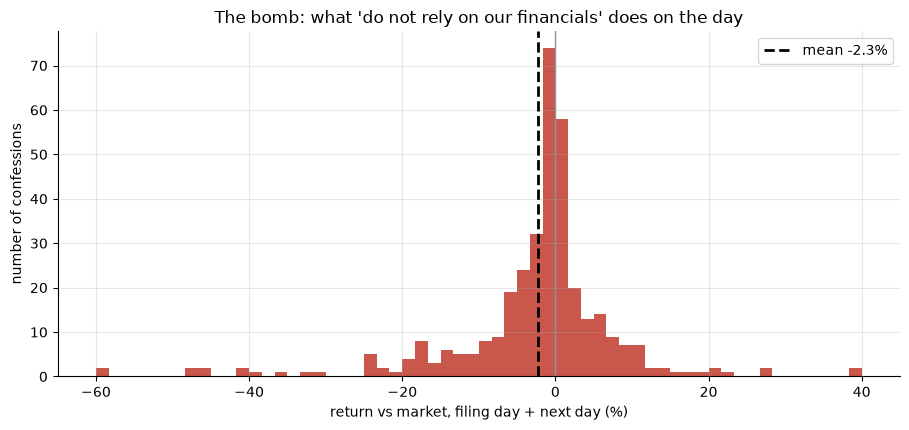

mean -2.32%  median -0.66%  n=359


In [2]:
if HAVE_REAL:
    ar0 = TAB['ar0'].to_numpy()*100
else:
    ar0 = np.random.default_rng(631).normal(R['ar0_mean'], 12, R['n_usable'])
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(np.clip(ar0, -60, 40), bins=60, color=RED, alpha=.85)
ax.axvline(0, c=GREY, lw=1)
ax.axvline(np.mean(ar0), c='k', ls='--', lw=2, label=f'mean {np.mean(ar0):+.1f}%')
ax.set_xlabel('return vs market, filing day + next day (%)')
ax.set_ylabel('number of confessions')
ax.set_title('The bomb: what \'do not rely on our financials\' does on the day')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean {np.mean(ar0):+.2f}%  median {np.median(ar0):+.2f}%  n={len(ar0)}')

The average confession costs about **-2.3%** versus the market in two days (median -0.7% — many 4.02s are technical bookkeeping fixes, a few are catastrophes). Real, instant, certified.

**Now the months after.** We start the clock at the close of the day *after* the filing and follow the stock vs the market.

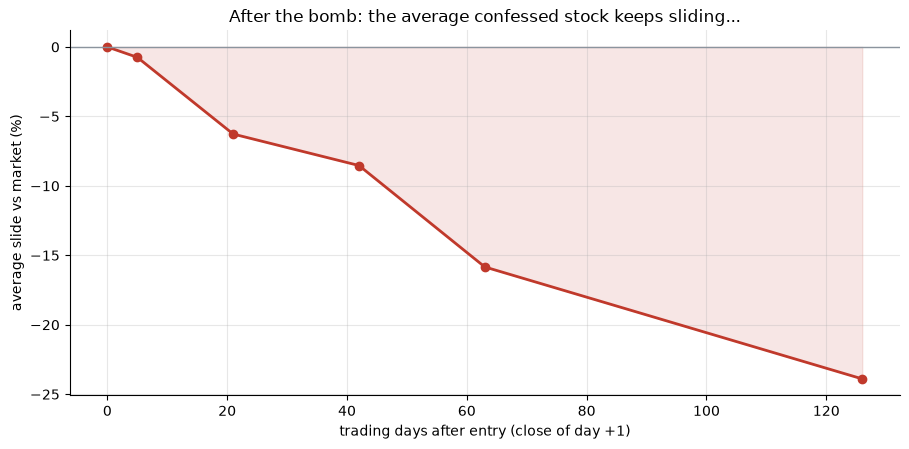

mean drift by horizon (%): {5: -0.75, 21: -6.27, 42: -8.54, 63: -15.84, 126: -23.9}


In [3]:
if HAVE_REAL:
    hz = st.horizon_curve(EV, CLOSE, DVOL, SPY)
    days = hz['days'].tolist(); cars = hz['car_pct'].tolist()
else:
    days = [h[0] for h in R['horizon']]; cars = [h[2] for h in R['horizon']]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot([0]+days, [0]+cars, marker='o', color=RED, lw=2)
ax.axhline(0, c=GREY, lw=1)
ax.fill_between([0]+days, [0]+cars, 0, color=RED, alpha=.12)
ax.set_xlabel('trading days after entry (close of day +1)')
ax.set_ylabel('average slide vs market (%)')
ax.set_title('After the bomb: the average confessed stock keeps sliding...')
plt.tight_layout(); plt.show()
print('mean drift by horizon (%):', dict(zip([int(d) for d in days], [round(c,2) for c in cars])))

Over the next **3 months** the average confessed stock slides another **-15.8%** vs the market — and it *looks* statistically solid. Case closed, market inefficient, short everything?

**Not so fast. Here's the twist.** What kind of company files a "do not rely"? Overwhelmingly: tiny, struggling, cash-burning microcaps (median trading volume in our panel: **$0.18M a day**). Stocks like that bleed *all the time*, confession or no confession. So we ran the control: the **same stocks**, a same-length window, **one year before** the event.

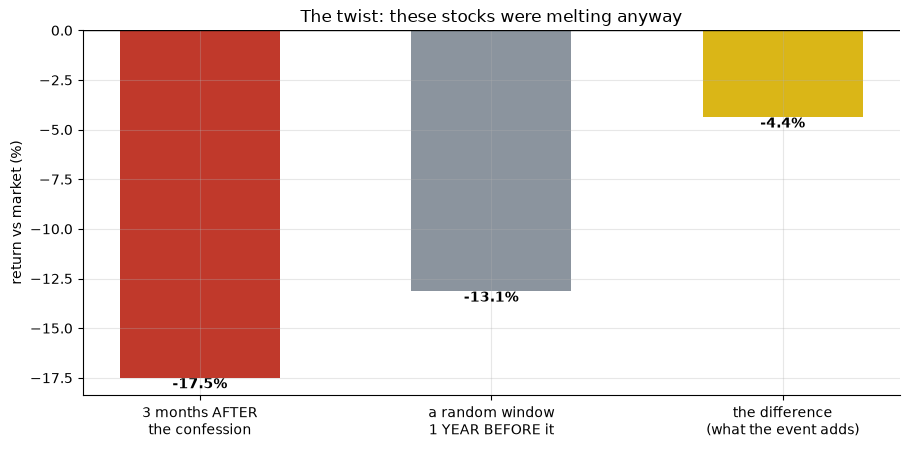

event -17.49%  placebo -13.13%  difference -4.36% (t=-0.85)


In [4]:
if HAVE_REAL:
    pl = st.chronic_decay_placebo(EV, CLOSE, DVOL, SPY)
    vals = [pl['event_pct'], pl['placebo_pct'], pl['diff_pct']]
    dt = pl['diff_t']
else:
    vals = [R['plc_event'], R['plc_plc'], R['diff']]; dt = R['diff_t']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
labs = ['3 months AFTER\nthe confession', 'a random window\n1 YEAR BEFORE it',
        'the difference\n(what the event adds)']
ax.bar(labs, vals, color=[RED, GREY, AMBER], width=.55)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='top', fontweight='bold')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('return vs market (%)')
ax.set_title('The twist: these stocks were melting anyway')
plt.tight_layout(); plt.show()
print(f'event {vals[0]:+.2f}%  placebo {vals[1]:+.2f}%  difference {vals[2]:+.2f}% (t={dt:+.2f})')

There it is. After the confession: **-17.5%**. In a random no-news window a year earlier: **-13.1%**. The confession's own contribution is only **-4.4%** — and statistically indistinguishable from zero (*t* ≈ −0.9, quants notebook). These are **melting ice cubes**: the 8-K doesn't start the melt, it's a thermometer reading taken partway through it.

**And the "trade"?** Shorting each confession for 3 months, hedged, does show a paper profit — but it's the melting-ice-cube exposure, not the event, and the names are unshortable in practice: sub-$1 prices, no shares to locate, ~$0.2M/day of volume, borrow fees that can exceed the drift. The quants notebook prices it at three cost levels; even where the model says "profit," the locate desk says "no."

## 5 · The verdict

- **The bomb is real** — -2.3% vs market in two days, certified. Markets price confessions *fast*.
- **The months-of-drift story is mostly an illusion of composition** — confessed stocks fall another -15.8% in 3 months, but the same stocks fell -13.1% in windows with no news at all. The event-specific part (-4.4%) certifies nothing.
- **Tradability — Mirage.** What survives costs on paper is a generic short-dying-microcaps trade you can't actually execute at size.
- **And remember the named bias:** the bankrupt are missing from our tape, so the true post-confession carnage is *worse* than measured — but proving the *underreaction* claim needs the event to add something beyond the melt, and on this tape it doesn't.

## 6 · Going further 🚪

- **Get the dead.** A survivorship-free tape (CRSP with delisting returns) would restore the bankrupt tail — the one place the event-specific drift could still be hiding.
- **Severity matters.** A 4.02 triggered by fraud is a different animal from one triggered by a lease-accounting technicality (or the 2021 SPAC-warrant wave). Reading the 8-K text, not just the item number, is the natural refinement.
- **The pipeline view.** Pair with [229-beneish-m-score](../../229-beneish-m-score/): the M-Score flags cooked books *before* the confession; this study shows the confession itself is priced in two days.

*Think three months of drift on hard-to-borrow microcaps is a business? Price the locate first — then we'll talk.*